# PORTADA

**GRUPO 3**

Integrantes:
- Juan Carlos Heredia Vallejo
- Jonathan Fernando Tisalema Lascano

<br>
**Nota:** A fin de identificar las modificaciones realizadas, las mismas serán identificadas por ** antes de su título o párrafo correspondiente.

<small>
Feedback recibido:

- Hard-coding" de Reglas de Negocio (Tipo de Cambio) definieron la transformación de moneda así: tipo_cambio = 0.053. "Harcodear" (escribir fijo) un valor tan volátil como una tasa de cambio es un riesgo operativo alto. Si ejecutan este notebook la próxima semana, el análisis financiero será erróneo porque la Lira Turca habrá fluctuado. En arquitecturas robustas, las variables volátiles deben gestionarse como Parámetros Externos o consultarse en tiempo real. Usar una librería como forex-python para traer la tasa del día automáticamente.
- Ineficiencia en Ingeniería de Características (Bucles vs. Vectorización) crearon la función grupo_etario(edad) y la aplicaron usando df["age"].apply(grupo_etario). Usar .apply() con una función de Python personalizada impide que Pandas use optimización vectorial, obligando a iterar fila por fila. Con 99,000 datos no se nota, pero con 10 millones, esto sería un cuello de botella. Para crear rangos o bins numéricos, siempre deben usar la función vectorizada nativa pd.cut.
</small>

La data utilizada para el análisis no presenta ficheros al ser un archivo .csv, sin embargo, a fin de mantener la práctica se realiza la carga de datos de UFC para carga y limpieza desde un archivo JSON, así como también, la carga de datos desde una API:.


###*Ejemplo de importar datos JSON y limpieza de variables:*

Carga de datos de UFC

In [ ]:
import pandas as pd
ufc = pd.read_json('https://raw.githubusercontent.com/tmprk/ufc-data-scrape/main/data/data_2023-01-16_19-58-46.json')
print('Datos UFC:')
display(ufc.head(2))
print(f'\n\nTamaño: {ufc.shape}')

Datos UFC:


,iso,first,last,weight_class,name,age,height,nickname,status,ufc_record,...,Sig_Strike_/_min,Sig_Strike_Accuracy,Sig_Strike_absorbed_/_min,Sig_Strike_defense,Avg_Takedown_/_15_min,Takedown_accuracy,Takedown_defense,Avg_sub_attempts_/_min,events,next
0,BY,Andrei,Arlovski,"Heavyweight (265 lb, 120 kg)",Andrei Arlovski,43,6 ft 3 in (1.91 m),The Pit Bull,Loss - UFC Fight Night 213 (Las Vegas) - Mar...,23–15 (1 NC),...,3.79,45%,3.20,57%,0.40,36%,76%,0.2,"[{'result': 'loss', 'opponent': 'Marcos Rogeri...",NaN
1,US,Stipe,Miocic,"Heavyweight (265 lb, 120 kg)",Stipe Miocic,40,6 ft 4 in (1.93 m),,,14–4,...,4.82,53%,3.82,54%,1.86,34%,68%,0.0,"[{'result': 'loss', 'opponent': 'Francis Ngann...",NaN




Tamaño: (583, 27)


El fichero/columna 'events' mantiene información específica por cada pelea, por lo cual es conveniente ampliar la información

In [ ]:
df_ampliada = ufc.explode("events", ignore_index=True) #Repite información para cada registro en el fichero 'events'
eventos = pd.json_normalize(df_ampliada["events"]) #Extrae la data de 'events'
ufc_eventos = pd.concat([df_ampliada.drop(columns=["events"]), eventos], axis=1) #asigna la información de 'events' con la información macro vista inicialmente

print('Eventos de UFC:')
display(ufc_eventos.head(2))
print(f'\n\nTamaño: {ufc_eventos.shape}')
print(f'\nInfo de data:')
print(ufc_eventos.info())

Eventos de UFC:


,iso,first,last,weight_class,name,age,height,nickname,status,ufc_record,...,Avg_sub_attempts_/_min,next,result,opponent,event,forBelt,date,method,round,time
0,BY,Andrei,Arlovski,"Heavyweight (265 lb, 120 kg)",Andrei Arlovski,43,6 ft 3 in (1.91 m),The Pit Bull,Loss - UFC Fight Night 213 (Las Vegas) - Mar...,23–15 (1 NC),...,0.2,NaN,loss,Marcos Rogerio de Lima,UFC Fight Night: Kattar vs. Allen,None,"Oct. 29, 2022",SUB Rear Naked Choke,1,1:50
1,BY,Andrei,Arlovski,"Heavyweight (265 lb, 120 kg)",Andrei Arlovski,43,6 ft 3 in (1.91 m),The Pit Bull,Loss - UFC Fight Night 213 (Las Vegas) - Mar...,23–15 (1 NC),...,0.2,NaN,win,Jake Collier,UFC Fight Night: Font vs. Vera,None,"Apr. 30, 2022",S-DEC,3,5:00




Tamaño: (4994, 34)

Info de data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4994 entries, 0 to 4993
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   iso                        4994 non-null   object 
 1   first                      4994 non-null   object 
 2   last                       4994 non-null   object 
 3   weight_class               4994 non-null   object 
 4   name                       4994 non-null   object 
 5   age                        4994 non-null   int64  
 6   height                     4994 non-null   object 
 7   nickname                   4994 non-null   object 
 8   status                     4994 non-null   object 
 9   ufc_record                 4994 non-null   object 
 10  mma_record                 4994 non-null   object 
 11  Reach                      4994 non-null   object 
 12  Stance                     4982 non-null   object 
 13  W           

**Identificación de tratamiento de variables:**
<small>
- La variable 'forBelt' no presenta ningun registro, es decir ningun evento de los registrados fue pelea por cinturon, por ende se puede identificar un dato binario como 0.
- La variable 'next' representa el siguiente evento, por lo que los datos NaN tienen una naturalidad (para últimos eventos).
- Las variables 'weight_class' y 'height' tienen varios datos (categoria, medida hispana y americana)
- Por lo que se opta por obtener la categoria de peso, extraer peso en kg y altura en m.
</small>

In [ ]:
ufc_eventos['forBelt']=0 # Asignar 0 en la variable 'forBelt'

ufc_eventos["category"] = ufc_eventos["weight_class"].str.extract(r"^(.*?)\s*\(") # Extraer la categoria de peso
ufc_eventos["weight_kg"] = (ufc_eventos["weight_class"].str.extract(r"(\d+)\s*kg").astype(float)) # Extraer peso en kg
ufc_eventos["height_m"] = (ufc_eventos["height"].str.extract(r"\(([\d.]+)\s*m\)").astype(float)) # Estraer altura en m

Revisión del tratamiento de variables:

In [ ]:
print(f"Categorias de peso: \n {ufc_eventos["category"].unique()}")
print("\nResumen de variables weight_kg y height_m:")
display(ufc_eventos[["weight_kg", "height_m"]].describe().T)

Categorias de peso: 
 ['Heavyweight' 'Light heavyweight' 'Middleweight' 'Welterweight'
 'Lightweight' 'Featherweight' 'Bantamweight' 'Flyweight'
 "Women's bantamweight" "Women's flyweight" "Women's strawweight"]

Resumen de variables weight_kg y height_m:


,count,mean,std,min,25%,50%,75%,max
weight_kg,4994.0,73.775330,17.362754,52.0,61.0,70.00,84.00,120.00
height_m,4994.0,1.775605,0.092008,1.5,1.7,1.78,1.85,2.01


###*Ejemplo de importar datos desde API:*

Consultar Aseguradoras con las que se Trabaja

In [ ]:
json_api_url_ramos = 'https://cotizador.segurossuarez.com/efi-api/areas/subarearamo'

# Leer directamente con pandas
df_json = pd.read_json(json_api_url_ramos)
df_ramos = pd.json_normalize(df_json['resultado'])

#elimino duplicados
df_ramos = df_ramos.drop_duplicates()
display(df_ramos)


,codigoArea,nombreRamoGrupo,codigoSubarea,nombreSubarea,aliasSubarea
0,3,FIANZAS,3,INDIVIDUALES,INDIVIDUALES
1,3,FIANZAS,5,FIANZAS,FIANZAS
2,1,GENERALES,8,PYMES,PYMES
5,1,GENERALES,4,MASIVOS,MASIVOS
6,1,GENERALES,7,PUBLICO,PUBLICO
7,1,GENERALES,2,CORPORATIVOS,CORPORATIVOS
8,1,GENERALES,3,INDIVIDUALES,INDIVIDUALES
9,2,VIDA ASISTENCIA MEDICA,2,CORPORATIVOS,CORPORATIVOS
10,2,VIDA ASISTENCIA MEDICA,4,MASIVOS,MASIVOS
11,2,VIDA ASISTENCIA MEDICA,7,PUBLICO,PUBLICO


# 1.- Selección de la fuente de Datos

## **Análisis de perfiles de compradores en Centros Comerciales de la India**

El presente estudio se basa en datos de transacciones de compra realizadas en 10 centros comerciales distintos de la India. El objetivo es identificar perfiles de los clientes y sus características según su comportamiento en los registros de compras, con el fin de identificar oportunidades que permitan impulsar las ventas, mejorar la captación y fidelización de clientes.

**Cómo:**<br>
Se analizarán variables demográficas y de comportamiento de compra, tales como: género, categoría de productos, monto de gasto, frecuencia de compra, método de pago y centro comercial visitado. Para ello, se trabajará con la base [customer_shopping_data.csv](https://www.kaggle.com/datasets/mehmettahiraslan/customer-shopping-dataset) la cual presenta las variables:
<small>
- **invoice_no**: Número de factura. Nominal. Una combinación de la letra “I” y un número entero de 6 dígitos asignado de manera única a cada operación.
- **customer_id**: Número de cliente. Nominal. Una combinación de la letra “C” y un número entero de 6 dígitos asignado de manera única a cada operación.
- **gender**: Variable de tipo cadena que indica el género del cliente.
- **age**: Variable entera positiva que representa la edad del cliente.
- **category**: Variable de tipo cadena que indica la categoría del producto adquirido.
- **quantity**: Cantidad de cada producto (ítem) por transacción. Numérica.
- **price**: Precio unitario. Numérico. Precio del producto por unidad en liras turcas (TL).
- **payment_method**: Variable de tipo cadena que indica el método de pago utilizado en la transacción (efectivo, tarjeta de crédito o tarjeta de débito).
- **invoice_date**: Fecha de la factura. Día en que se generó la transacción.
- **shopping_mall**: Variable de tipo cadena que indica el nombre del centro comercial donde se realizó la transacción.
</small>

**Importancia:**<br>
Comprender el comportamiento de los clientes es clave previo a implementar estrategias comerciales. En un contexto altamente competitivo como el retail, contar con información basada en datos permite pasar de decisiones intuitivas a decisiones sustentadas e informadas. Este análisis resulta especialmente relevante porque permite:
- Identificar qué tipos de clientes generan mayor valor.
- Detectar categorías de productos con mayor potencial de crecimiento.
- Analizar diferencias de comportamiento entre centros comerciales.
- Entender cómo variables demográficas influyen en el gasto y la preferencia de consumo.
- Analizar variables temporales para identificar los períodos en los que se registra un mayor volumen de ventas.

# 2.- Adquisición de Datos


## 2.1. Carga de datos

In [ ]:
# Librerias
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Importar base de datos desde Kaggle
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "mehmettahiraslan/customer-shopping-dataset",
    "customer_shopping_data.csv",
    pandas_kwargs={"sep": ",","encoding": "latin1"}
)
df

Using Colab cache for faster access to the 'customer-shopping-dataset' dataset.


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon
...,...,...,...,...,...,...,...,...,...,...
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,21/09/2022,Kanyon
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,22/09/2021,Forum Istanbul
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,28/03/2021,Metrocity
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,16/03/2021,Istinye Park


# 3.- Limpieza y Exploración Inicial


##3.1. Mostrar Primeras Filas

In [ ]:
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


##3.2. Transformación de la variable 'invoice_date' a tipo date

In [ ]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)
print(f"Tipo de dato 'invoice_date': {df['invoice_date'].dtype}")

Tipo de dato 'invoice_date': datetime64[ns]


##3.3. Utilizar .info() para ver tipos de datos y valores no nulos.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      99457 non-null  object        
 1   customer_id     99457 non-null  object        
 2   gender          99457 non-null  object        
 3   age             99457 non-null  int64         
 4   category        99457 non-null  object        
 5   quantity        99457 non-null  int64         
 6   price           99457 non-null  float64       
 7   payment_method  99457 non-null  object        
 8   invoice_date    99457 non-null  datetime64[ns]
 9   shopping_mall   99457 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 7.6+ MB


##3.4. Usar .describe() para estadísticas descriptivas.

In [ ]:
df.describe()

,age,quantity,price,invoice_date
count,99457.000000,99457.000000,99457.000000,99457
mean,43.427089,3.003429,689.256321,2022-02-04 02:46:59.783424
min,18.000000,1.000000,5.230000,2021-01-01 00:00:00
25%,30.000000,2.000000,45.450000,2021-07-19 00:00:00
50%,43.000000,3.000000,203.300000,2022-02-05 00:00:00
75%,56.000000,4.000000,1200.320000,2022-08-22 00:00:00
max,69.000000,5.000000,5250.000000,2023-03-08 00:00:00
std,14.990054,1.413025,941.184567,NaN


##3.5. Identificar y cuantificar valores nulos (.isnull().sum()).

In [ ]:
nulos = df.isnull().sum()
resumen_nulos = pd.DataFrame({
    "Columna": nulos.index,
    "Valores Nulos": nulos.values
})
resumen_nulos

,Columna,Valores Nulos
0,invoice_no,0
1,customer_id,0
2,gender,0
3,age,0
4,category,0
5,quantity,0
6,price,0
7,payment_method,0
8,invoice_date,0
9,shopping_mall,0


##3.6. ** Transformacion a Moneda Local


**Con el manejo de la libreria forez-python podemos obtener el tipo de cambio en tiempo real y por lo cual podemos observar que enverdad se presenta un cambio en los valores asignados con anterioridad de una manera de transformación fija. Esto es muy importante y util ya que permite tener valores actualizados y pudiendo tener estimaciones precisas de valores de productos para los diferentes tipos de analisis **

In [ ]:
!pip install forex-python # Instalar la librería
from forex_python.converter import CurrencyRates
c = CurrencyRates()
tipo_cambio2 = c.get_rate('TRY', 'USD')

tipo_cambio = 0.053  # 1 TL = 0.053 USD
df['price_usd_anterior'] = (df['price'] * tipo_cambio).round(2)
df['price_usd'] = (df['price'] * tipo_cambio2).round(2)
display(df)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,price_usd,price_usd2,price_usd_anterior
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon,34.22,34.22,79.52
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,41.06,41.06,95.43
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity,6.84,6.84,15.90
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM,68.44,68.44,159.05
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon,1.38,1.38,3.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,21/09/2022,Kanyon,1.34,1.34,3.11
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,22/09/2021,Forum Istanbul,0.24,0.24,0.55
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,28/03/2021,Metrocity,0.24,0.24,0.55
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,16/03/2021,Istinye Park,95.79,95.79,222.60


##3.7. ** Creación de variable de grupo etario

** Este cambio se hace para mejorar la eficiencia del código. En lugar de aplicar una función fila por fila con .apply(), se utiliza pd.cut, que es vectorizado y procesa toda la columna a la vez, lo que hace que el cálculo sea mucho más rápido y escalable para grandes volúmenes de datos. Además, mantiene la misma lógica de agrupamiento y permite generar categorías ordenadas por promedio de edad **

In [ ]:
#Creamos bins de 5 años empezando desde 1 hasta el máximo de edad + 5
max_edad = df['age'].max()
bins = list(range(1, max_edad + 5, 5))
labels = [f"{i}-{i+4} años" for i in bins[:-1]]  # Crear etiquetas

# Asignar grupo etario usando pd.cut
df['gruet'] = pd.cut(df['age'], bins=bins, labels=labels, right=False, include_lowest=True)

#Crear categoría ordenada por edad promedio del grupo
orden_cat = df.groupby('gruet', observed=False)['age'].mean().sort_values().index.to_list()
df['gruet'] = pd.Categorical(df['gruet'], categories=orden_cat, ordered=True)

# 4️⃣ Comprobar resultados
print(df[['age','gruet']])

       age       gruet
0       28  26-30 años
1       21  21-25 años
2       20  16-20 años
3       66  66-70 años
4       53  51-55 años
...    ...         ...
99452   45  41-45 años
99453   27  26-30 años
99454   63  61-65 años
99455   56  56-60 años
99456   36  36-40 años

[99457 rows x 2 columns]


Al tratarse de un archivo en formato CSV, la estructura de los datos es tabular, por lo que no fue necesario realizar procesos de filtrado o normalización de objetos anidados. Durante la exploración inicial del dataset no se identificaron valores nulos que requirieran imputación, únicamente transformación del tipo de dato. No obstante, con el objetivo de mejorar la interpretación y el análisis de los resultados, se realizó la conversión de la moneda original a la moneda local así como la asginación de grupo etario, permitiendo una comprensión más intuitiva y precisa en el conjunto de datos.

# 4.- Exploración de Datos (Transformación y Procesamiento de Datos)

## 4.1. Distribución de compras por centro comercial

A fin de identificar el centro comercial con mayor flujo comercial, se opta por analizar el número de transacciones y valor monetario presentes en los centros comerciales en el periodo (01-ene-2021 a 08-mar-2023).

Para ello se opta por calcular el total de la compra:  $total\_sale\_usd = price\_usd * quantity$

In [ ]:
#Calcular valor total de la factura
df["total_sale_usd"] = df["quantity"] * df["price_usd"]

Comparación de volumen de ventas en número de transacciones y monto por centro comercial, ordernado de forma descendiente por monto de ventas:

,num_compras,ventas_usd
shopping_mall,,
Mall of Istanbul,19943,2696252.88
Kanyon,19823,2679385.41
Metrocity,15011,1977056.55
Metropol AVM,10161,1345142.18
Istinye Park,9781,1304804.77
Zorlu Center,5075,683757.58
Cevahir AVM,4991,670195.20
Viaport Outlet,4914,663632.82
Emaar Square Mall,4811,657524.93


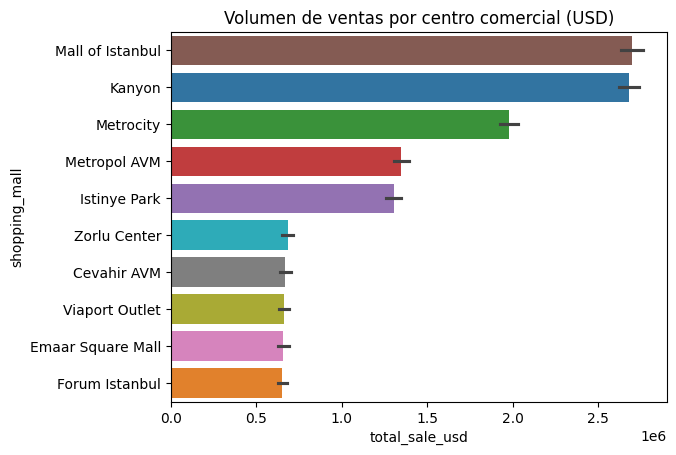

In [ ]:
datos_mall = df.groupby('shopping_mall').agg( #Agrupar por mall
    num_compras=('total_sale_usd', 'count'),  #contar comprasa
    ventas_usd=('total_sale_usd', 'sum') #Sumar total de compras en usd
).sort_values(by='ventas_usd', ascending=False) #ordenar por ventas usd de mayor a menor
display(datos_mall)

#Grafico de barras ordenado de mayor a menor
sns.barplot(data=df, y='shopping_mall', x='total_sale_usd', estimator=np.sum, hue='shopping_mall',
            order = df.groupby("shopping_mall")["total_sale_usd"].sum().sort_values(ascending=False).index.tolist())
plt.title('Volumen de ventas por centro comercial (USD)')
plt.show()

**¿Qué centros comerciales presentan mayor volumen de ventas?**

Se ha identificado que los centros comerciales *Mall of Istanbul* y *Kanyon* son los que presentan mayor volumen de ventas y cantidad de transacciones en el periodo estudiado.

A fin de identificar si el comportamiento de concentración de compras se debe a un factor demográfico, se considera analizar la densidad por variable demográfica presente en las compras realizadas por mall.

Para ello es importante trabajar con datos de cliente únicos por centro comercial ya que un mismo cliente puede realizar múltiples compras. En caso de considerar todas las transacciones, estos clientes quedarían sobrerrepresentados, distorsionando la distribución real de edades. Por ello, al eliminar duplicados se garantiza que cada cliente tenga el mismo peso en el análisis, permitiendo comparar adecuadamente el perfil etario entre centros comerciales.

/tmp/ipython-input-939068225.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_unique, x="age", y="shopping_mall", palette="Set2")


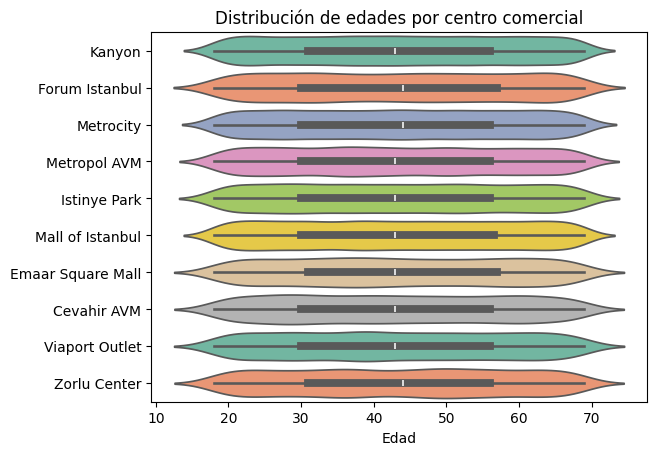

In [ ]:
# Eliminar duplicados: un cliente solo cuenta una vez por centro comercial
df_unique = df.drop_duplicates(subset=["customer_id", "shopping_mall", "gender"])
# Gráfico de violin (distibución de edades) en cada mall
sns.violinplot(data=df_unique, x="age", y="shopping_mall", palette="Set2")
plt.title('Distribución de edades por centro comercial')
plt.ylabel(None); plt.xlabel('Edad')
plt.show()

**¿Los centros comerciales presentan alguna concentración de compras por edad?**

No se identifica una tendencia/patrón de compras por edad de los clientes en cada centro comercial. Según la gráfica previa, las edades son muy variadas y se encuentran distribuidas en proporciones similares.

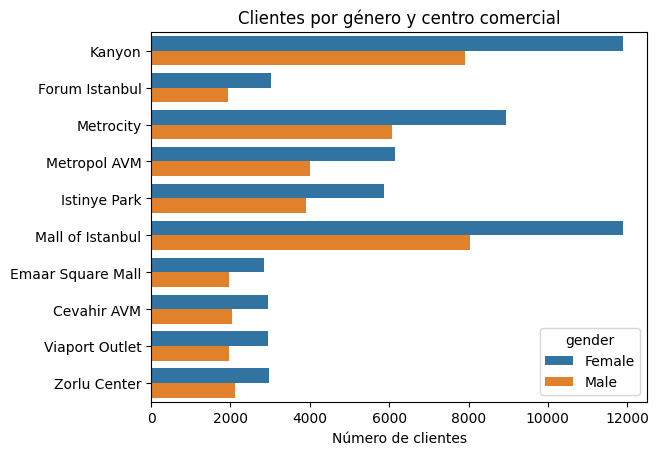

In [ ]:
#Grafico de volumen de ventas por mall y sexo
sns.countplot(df_unique, y="shopping_mall", hue="gender")
plt.xlabel("Número de clientes")
plt.ylabel(None)
plt.title("Clientes por género y centro comercial")
plt.show()


**¿Qué genero realiza más compras?**

A nivel general, se puede observar que existe mayor cantidad de clientes mujeres que hombres en las compras realizadas. Sin considerar la frecuencia o valor de compra.

## 4.2. Identificar el comportamiento de método de pago en cada centro comercial

**Ventas totales por categoría y por método de pago**

Que buscamos:

Identificar cómo se distribuyen las ventas totales según el método de pago, tanto por centro comercial como por categoría de producto, expresándolo en porcentajes para facilitar la comparación. De esta manera, se pretende comprender las preferencias de pago de los clientes en cada centro comercial y en cada tipo de producto, con el fin de detectar patrones de comportamiento y apoyar la toma de decisiones comerciales relacionadas con estrategias de cobro, promociones y gestión de medios de pago.

Que obtenemos:

La proporción de frecuencia de uso de 'x' método de pago en contraste con el saldo de ventas presente, presenta un comportamiento similar. Esto podría sugerir que el monto de compra es homogéneo sin importar el método de pago, no obstante, las personas que realizan compras en los centros comerciales de la India, mayormente realizan pagos en efectivo.

In [ ]:
# Pivotear tabla filas (centros comerciales) y columnas (metodos de pago) con el valor de ventas totales
tabla = pd.pivot_table( df, values="total_sale_usd", index="shopping_mall",
    columns="payment_method", aggfunc="sum", fill_value=0)
# Obtener proporciones por fila
tabla_prop = tabla.div(tabla.sum(axis=1), axis=0)
print('\n\n> Propoción de saldos por método de pago por centro comercial:')
display(tabla_prop*100)

# Pivotear tabla filas (centros comerciales) y columnas (categoria de producto) con el valor de ventas totales
tabla2 = pd.pivot_table( df, values="total_sale_usd", index="category",
    columns="payment_method", aggfunc="sum", fill_value=0)
# Obtener proporciones por fila
tabla_prop2 = tabla2.div(tabla2.sum(axis=1), axis=0)
print('\n\n> Propoción de saldos por método de pago por categoria:')
display(tabla_prop2*100)



> Propoción de saldos por método de pago por centro comercial:


payment_method,Cash,Credit Card,Debit Card
shopping_mall,,,
Cevahir AVM,44.506771,34.571064,20.922166
Emaar Square Mall,46.197283,34.240443,19.562274
Forum Istanbul,42.649112,35.375543,21.975345
Istinye Park,44.751093,35.644273,19.604634
Kanyon,45.419802,33.489453,21.090745
Mall of Istanbul,45.057850,34.913971,20.028179
Metrocity,44.603882,35.990043,19.406075
Metropol AVM,44.840500,35.463201,19.696299
Viaport Outlet,45.394254,35.677190,18.928556




> Propoción de saldos por método de pago por categoria:


payment_method,Cash,Credit Card,Debit Card
category,,,
Books,45.527505,33.624075,20.848420
Clothing,45.009047,34.519921,20.471031
Cosmetics,43.614837,36.135118,20.250045
Food & Beverage,44.225228,35.658972,20.115800
Shoes,44.750250,35.401430,19.848320
Souvenir,43.169209,36.034068,20.796723
Technology,44.825521,35.418368,19.756111
Toys,45.487615,35.259902,19.252483


El tipo de pago a breves rasgos se podría suponer que es el efectivo, sin embargo hay que consierar que el usar tarjetas es un mundo similar (crédito y débito), por ello aunque por separado presente una porporción menor, las facilidades de pago o promociones pueden ir orientadas con el uso de tarjetas, considerando que no es un caso aislado de un centro comercial, es un comportamiento a nivel general.

## 4.3. Análisis por centro comercial y método de pago (Detalle)

Con este agrupamiento podemos analizar:

 * Comparar el desempeño de ventas por mall

* Analizar la preferencia de método de pago en cada ubicación

* Detectar qué combinaciones generan mayor ingreso promedio

Este análisis permite comparar el comportamiento de ventas entre distintos centros comerciales y métodos de pago. Proporciona una visión clara de cómo varían los ingresos y el volumen de transacciones según la ubicación y la forma de pago, lo que resulta clave para la toma de decisiones operativas, financieras y comerciales.

In [ ]:
ventas_por_mall_pago = df.groupby(
    ["shopping_mall", "payment_method"]
).agg(
    total_ingresos_usd=("price_usd", "sum"),
    ventas_promedio_usd=("price_usd", "mean"),
    total_operaciones=("invoice_no", "count")
).reset_index()
display(ventas_por_mall_pago)

,shopping_mall,payment_method,total_ingresos_usd,ventas_promedio_usd,total_operaciones
0,Cevahir AVM,Cash,80523.92,36.141795,2228
1,Cevahir AVM,Credit Card,63720.89,35.818375,1779
2,Cevahir AVM,Debit Card,37738.87,38.352510,984
3,Emaar Square Mall,Cash,81947.03,38.763969,2114
4,Emaar Square Mall,Credit Card,61839.66,36.462064,1696
5,Emaar Square Mall,Debit Card,35903.83,35.867962,1001
6,Forum Istanbul,Cash,75777.08,34.712359,2183
7,Forum Istanbul,Credit Card,62731.16,35.846377,1750
8,Forum Istanbul,Debit Card,38302.60,37.773767,1014
9,Istinye Park,Cash,159635.80,35.986429,4436


El promedio por venta, sustenta la suposición del punto anterior, que las compras son homogeneas, al presentar valores cercanos.

## 4.4. Identificación de categorías estrella (más vendidas)
Si bien se ha identificado los centros comerciales en donde se presenta mayor flujo de dinero, es importante conocer la categoría de productos que promueven la trasaccionalidad.

Este agrupamiento permite identificar el desempeño de cada categoría de producto en términos de ingresos y volumen de ventas. A partir de este análisis se puede determinar qué categorías generan mayores ingresos, cuáles tienen un mayor valor promedio por transacción y cuáles concentran más operaciones, facilitando la priorización de categorías estratégicas dentro del negocio.

In [ ]:
# Análisis de categorías por cantidad de productos y valor (USD)
categorias_resumen = df.groupby('category').agg(  #Agrupar por categoria
    num_articulos=('quantity', 'sum'),  #contar el número de productos vendidos
    total_usd=('total_sale_usd', 'sum')  #sumar el total de ventas realizadas
).assign(
    prom_venta_usd=lambda x: x['total_usd'] / x['num_articulos']
).sort_values(by='total_usd', ascending=False) #ordenar de forma descendiente
display(categorias_resumen)

,num_articulos,total_usd,prom_venta_usd
category,,,
Clothing,103558,6041807.33,58.342256
Shoes,30217,3527442.71,116.737026
Technology,15021,3066704.55,204.161144
Cosmetics,45465,359887.69,7.915709
Toys,30321,211015.90,6.959398
Food & Beverage,44277,45069.05,1.017889
Books,14982,44208.77,2.950792
Souvenir,14871,33725.89,2.267897


Se identifican como las 3 principales categorias de consumo (considerando su nivel de ventas): Clothing, Shoes y Technology las cuales serán sujeto de análisis para identificar comportamiento específicos, ya que podemos intuir que son los productos mas vendidos o con acojida. **Se opta por realizar un filtro de las 3 principales categorías a fin de identificar posibles perfiles de riesgo en cada uno de ellos.**

Por otro lado, el precio promedio de presenta un orden inverso para las 3 principales categorías siendo tecnología la más rentable/costosa, posterioemente zapatados y finalmente ropa.

In [ ]:
#Filtrar subset con categorias principales
df_cat = df[df['category'].isin(['Clothing', 'Shoes', 'Technology'])]

## 4.5. Perfil de clientes por categoria

Volumen de compras por categoria, desagregado por sexo:

Con este análisis se busca entender cómo se distribuyen las ventas por rango de edad dentro de cada categoría de producto, identificando qué grupos de clientes contribuyen más a las ventas de Clothing, Shoes y Technology. El objetivo es segmentar el mercado según edades y categorías para tomar decisiones estratégicas de marketing, promociones y desarrollo de productos, enfocándose en los grupos con mayor impacto económico

In [ ]:
tabla_gruet = df_cat.groupby(['category','gruet']).agg(total_ventas=('total_sale_usd', 'sum')) #Se realiza el calculo de total de ventas por grupo etario y categoria.
tabla_gruet = tabla_gruet.pivot_table(index='category', columns='gruet') # Converit a data pivote
tabla_prop_g = tabla_gruet.div(tabla_gruet.sum(axis=1), axis=0) # otener totales por filas
(tabla_prop_g * 100).round(2) #Imprimir resultado

/tmp/ipython-input-310867709.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_gruet = df_cat.groupby(['category','gruet']).agg(total_ventas=('total_sale_usd', 'sum')) #Se realiza el calculo de total de ventas por grupo etario y categoria.
/tmp/ipython-input-310867709.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabla_gruet = tabla_gruet.pivot_table(index='category', columns='gruet') # Converit a data pivote


total_ventas                                              \
gruet        16-20 años 21-25 años 26-30 años 31-35 años 36-40 años   
category                                                              
Clothing           5.58       9.66       9.95       9.16       9.70   
Shoes              5.89       9.63      10.00       9.24       9.88   
Technology         4.56       9.91       9.81       8.82      11.19   

                                                                              
gruet      41-45 años 46-50 años 51-55 años 56-60 años 61-65 años 66-70 años  
category                                                                      
Clothing         9.61       9.85       9.69       9.53       9.55       7.72  
Shoes           10.10       9.32       9.66       9.06       9.76       7.46  
Technology      10.10       9.27       9.46       9.43       9.77       7.67

**A nivel de categoría, ¿existe concentración de un grupo etario en sus compras?**

No se presenta una concentración por grupo etario en las distintas compras por categoria, lo cual no presenta un perfil por edad

Como resultado obtenemos una tabla de proporciones en porcentaje que muestra, para cada categoría, el aporte relativo de cada grupo de edad al total de ventas. Esto nos permite visualizar patrones de compra, detectar qué edades son más relevantes para cada tipo de producto y orientar estrategias comerciales y de comunicación para maximizar la rentabilidad según el perfil de los clientes.

Aunque en esta ocasión no se detectó proporciones con un mayor concentración, se recomienda considerar esta práctica para identificar posibles perfiles por edades.

## 4.6. Análisis de temporalidad

El comportamiento de ventas puede ser estacional (presentarse con mayor o menor frecuencia en un periodo específico), para ello se analizar el comportamiento de ventas conforme el tiempo:

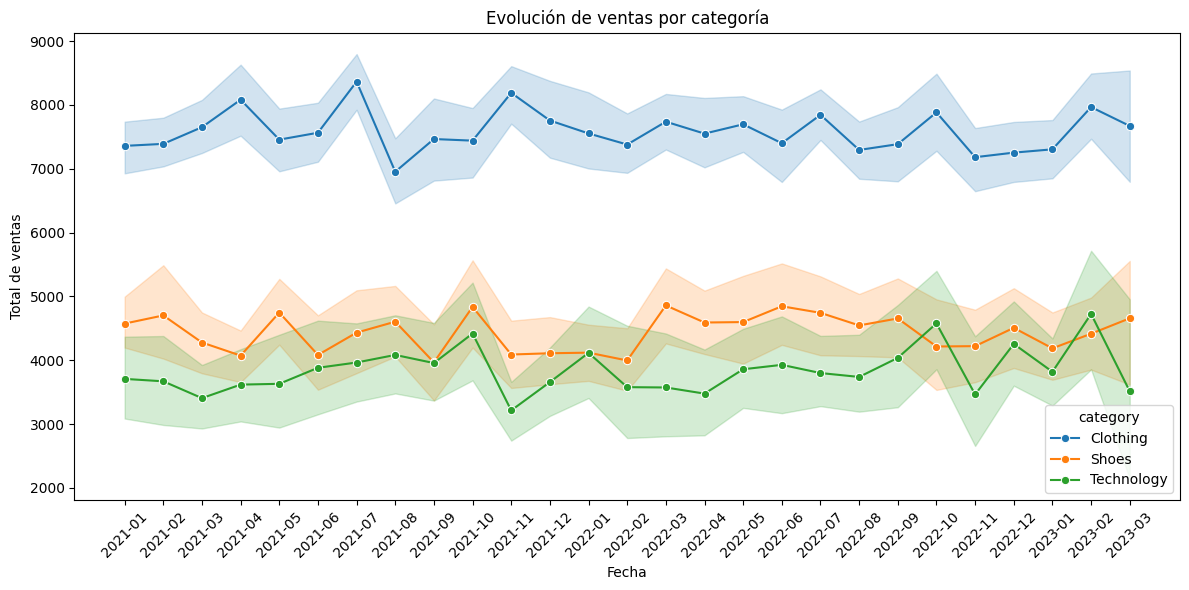

In [ ]:
plt.figure(figsize=(12, 6))
# Calcular el total de ventas por categoria y fecha
df_agg = (df_cat.groupby(["invoice_date", "category"], as_index=False).agg(total_ventas=("total_sale_usd", "sum")))
df_agg['date_month'] = df_agg['invoice_date'].dt.strftime('%Y-%m')
# Grafico de lineas
sns.lineplot(data=df_agg, x="date_month", y="total_ventas", hue="category", marker='o')
plt.title("Evolución de ventas por categoría")
plt.xlabel("Fecha")
plt.ylabel("Total de ventas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La categoría de ropa y zapatos no presentan un patrón claro en un pico de compras ya que estas no muestran un comportamiento repetitivo, por lo que sus picos pueden deberse a eventos específicos como lanzamientos, descuentos de apertura, entre otros.

Por otro lado, la categoría de tecnología presenta un pico al alza y bajada en octubre y noviembre respectivamente en los años 2021 y 2022, lo cual puede sugerir un comportamiento de compra habitual en la India.

## 4.7. Extraer mes de la fecha de compra

Que obtenemos con esta nueva columna:
Nos permite analizar tendencias temporales.

* Comparaciones evolutivas por tipo de compra

* Visualizaciones más claras


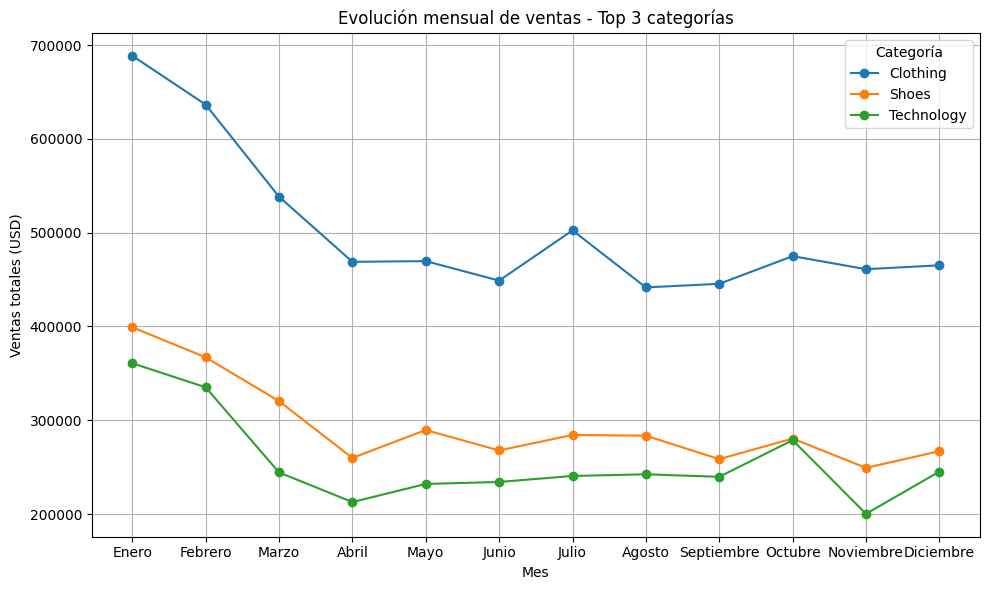

In [ ]:
# Extraer número de mes
df["invoice_month_num"] = df["invoice_date"].dt.month
# Diccionario de meses en español
meses_es = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
    5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
    9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}
# Crear columna con el mes en español
df["invoice_month"] = df["invoice_month_num"].map(meses_es)
ventas_cat_mes = (
    df.groupby(["category", "invoice_month"])["total_sale_usd"]
      .sum()
      .reset_index()
)
#obtenemos las 3 categorias
df_plot = ventas_cat_mes.sort_values("invoice_month")
top_3_categories = (
    df.groupby("category")["total_sale_usd"]
      .sum()
      .sort_values(ascending=False)
      .head(3)
      .index
)
df_top3 = df.loc[df["category"].isin(top_3_categories)].copy()


#ordenar correcto de meses
orden_meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
               "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

df_top3["invoice_month"] = pd.Categorical(
    df_top3["invoice_month"],
    categories=orden_meses,
    ordered=True
)

# Agrupar por categoría y mes
ventas_cat_mes = (
    df_top3.groupby(
        ["category", "invoice_month"],
        observed=True
    )["total_sale_usd"]
    .sum()
    .reset_index()
)

#Gráfico de líneas
plt.figure(figsize=(10,6))

for cat in top_3_categories:
    data_cat = ventas_cat_mes[ventas_cat_mes["category"] == cat]
    plt.plot(
        data_cat["invoice_month"],
        data_cat["total_sale_usd"],
        marker="o",
        label=cat
    )

plt.title("Evolución mensual de ventas - Top 3 categorías")
plt.xlabel("Mes")
plt.ylabel("Ventas totales (USD)")
plt.legend(title="Categoría")
plt.grid(True)
plt.tight_layout()
plt.show()

Con el gráfico de la evolución mensual de las ventas de las tres categorías principales es posible identificar patrones claros de comportamiento a lo largo del tiempo. Por otro lado, este análisis permite segmentar el mercado al reconocer en qué meses cada categoría presenta mayor rentabilidad, lo que facilita enfocar estrategias comerciales y promocionales en los periodos de mayor demanda, optimizando así el aprovechamiento del potencial de ventas de cada tipo de producto

## 4.8. Análisis de compradores

En base a los puntos anteriores, no se ha detectado un perfil claro de cliente por Centro Comercial o Categoría.
Por ello, otra óptica de estudio es el consolidar las compras que ha realizado 'x' cliente, e identificar los mayores compradores.

In [ ]:
top_customers = df.groupby(['customer_id', 'gruet', 'gender']).agg( #agregar por cliente y características únicas
    compras_n_malls=('shopping_mall', 'nunique'), #en cuantos malls ha realizado compras
    categorias_compradas=('category', 'nunique'), #cuantas categorias ha comprado
    total_compras=('total_sale_usd', 'sum') #cuantas compras ha realizado
).sort_values(by='total_compras', ascending=False) #ordenar por total de compras en forma descendiente

print(f"\nMáximo de centros comerciales visitados por un mismo cliente: {top_customers['compras_n_malls'].max()}")
print(f"Máximo de distintas categorias compradas por un mismo cliente: {top_customers['categorias_compradas'].max()}")
print(f"Máximo de compras realizadas por un cliente: {top_customers['total_compras'].max()}")


/tmp/ipython-input-96266712.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_customers = df.groupby(['customer_id', 'gruet', 'gender']).agg( #agregar por cliente y características únicas



Máximo de centros comerciales visitados por un mismo cliente: 1
Máximo de distintas categorias compradas por un mismo cliente: 1
Máximo de compras realizadas por un cliente: 1391.25


Según los resultados anteriores, nigun cliente presenta compras en distintos centros comerciales ni ha comprado más de una categoría de producto. Esto puede sugerir que los clientes en la India presentan una fidelidad sumamente exclusiva en la compra de sus productos, aunque siendo realista es sumamente raro que se presente este caso, por lo se podría inferir que esta data fue creada por secciones y no suponiendo una aleatoriedad en sus registros.

## 4.9. Clasificar el monto de compra según el valor

Que obtenemos con esta nueva columna:

Permite conocer el ingreso real generado por cada transacción, considerando cantidad y precio,conviertiendo un valor numérico en una categoría analítica para poder realizar:

* Análisis de ingresos

* Identificación de tickets altos

* Comparación entre clientes, categorías y centros comerciales


In [ ]:
# Calcular percentiles
p25 = df["total_sale_usd"].quantile(0.25)
p75 = df["total_sale_usd"].quantile(0.75)
# Clasificar tipo de compra según percentiles
def clasificar_compra(x):
    if x >= p75: return "Alta"
    elif x >= p25: return "Media"
    else: return "Baja"
df["purchase_type"] = df["total_sale_usd"].apply(clasificar_compra)
display(df)


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,price_usd,gruet,total_sale_usd,invoice_month_num,invoice_month,purchase_type
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon,79.52,26-30 años,397.60,8,Agosto,Alta
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,95.43,21-25 años,286.29,12,Diciembre,Alta
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity,15.90,16-20 años,15.90,11,Noviembre,Baja
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol AVM,159.05,66-70 años,795.25,5,Mayo,Alta
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon,3.21,51-55 años,12.84,10,Octubre,Baja
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,2022-09-21,Kanyon,3.11,41-45 años,15.55,9,Septiembre,Baja
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,2021-09-22,Forum Istanbul,0.55,26-30 años,1.10,9,Septiembre,Baja
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,2021-03-28,Metrocity,0.55,61-65 años,1.10,3,Marzo,Baja
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,2021-03-16,Istinye Park,222.60,56-60 años,890.40,3,Marzo,Alta


Con este proceso obtenemos una segmentación de las compras según su valor relativo, calculando primero el monto total de cada venta y luego clasificándolas en bajas, medias y altas utilizando los percentiles 25 y 75. Esto nos permite identificar qué transacciones representan mayor valor económico dentro del conjunto de datos, facilitando el análisis del comportamiento de compra y apoyando la toma de decisiones enfocadas en estrategias comerciales y de segmentación basadas en el nivel de gasto.

**¿Qué método de pago se realiza con mayor frecuencia?**

La proporción de frecuencia de uso de 'x' método de pago en contraste con el saldo de ventas presente, presenta un comportamiento similar. Esto podría sugerir que el monto de compra es homogéneo sin importar el método de pago, no obstante, las personas que realizan compras en los centros comerciales de la India, mayormente realizan pagos en efectivo.

# 5.- Insights



## 5.1. ¿Qué género es el que realiza más compras?

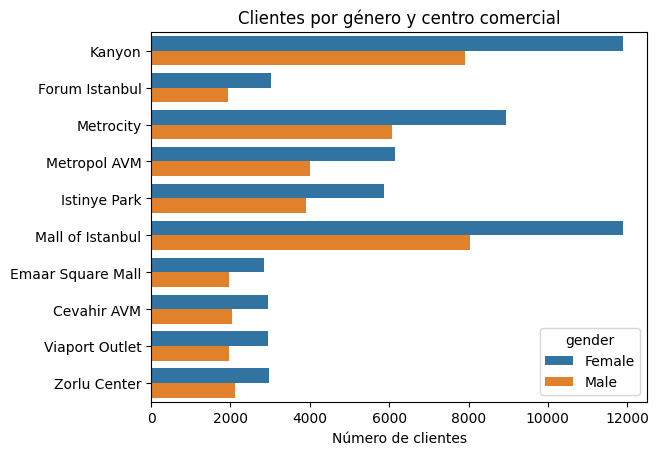

In [ ]:
sns.countplot(data=df_unique, y="shopping_mall", hue="gender")
plt.xlabel("Número de clientes")
plt.ylabel(None)
plt.title("Clientes por género y centro comercial")
plt.show()

Mediante este gráfico es posible identificar qué centros comerciales reciben mayor afluencia de mujeres que hombres. Aunque el comportamiento de ser visitados por más mujeres que hombres, en el caso de existir eventos distintos, se puede identificar qué centros comerciales podrían ser más adecuados para ofrecer productos dirigidos a un género específico o diseñar estrategias comerciales y promociones que resulten más atractivas para cada público.

## 5.2. ¿Que tipo de producto presenta un comportamiento cíclico en el periodo estudiado?



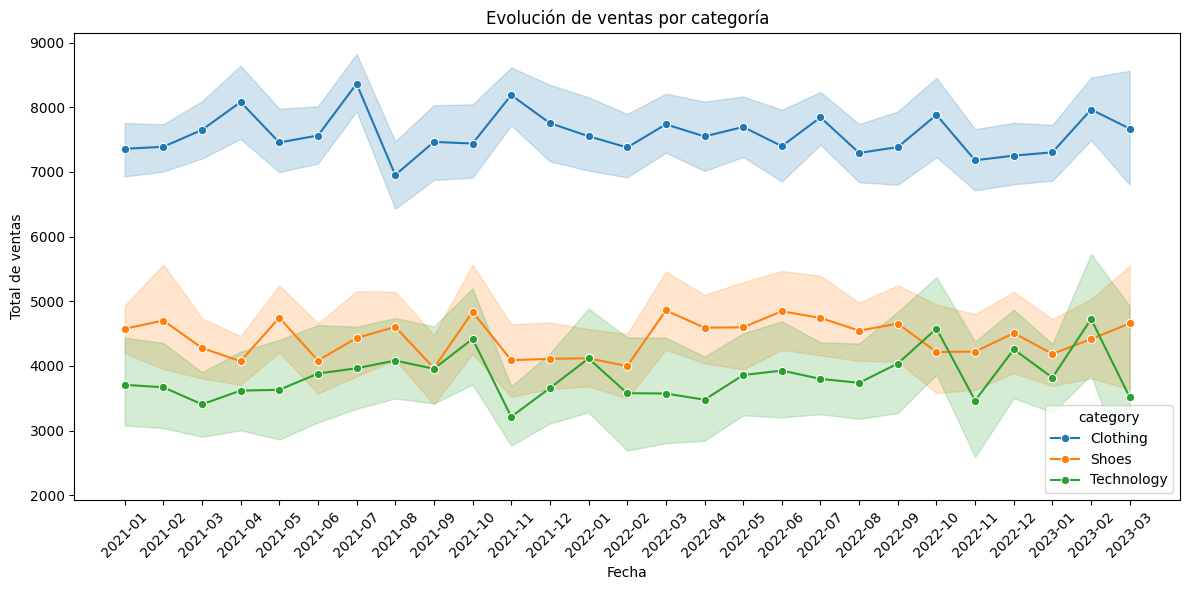

In [ ]:
plt.figure(figsize=(12, 6))
# Calcular el total de ventas por categoria y fecha
df_agg = (df_cat.groupby(["invoice_date", "category"], as_index=False).agg(total_ventas=("total_sale_usd", "sum")))
df_agg['date_month'] = df_agg['invoice_date'].dt.strftime('%Y-%m')
# Grafico de lineas
sns.lineplot(data=df_agg, x="date_month", y="total_ventas", hue="category", marker='o')
plt.title("Evolución de ventas por categoría")
plt.xlabel("Fecha")
plt.ylabel("Total de ventas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Con el gráfico de evolución de ventas por categoría (top 3) se obtiene una visión clara del comportamiento de cada tipo de producto a lo largo de los últimos dos años, identificando períodos de crecimiento o disminución. Esta información permite proyectar tendencias futuras, orientar la adquisición de productos específicos y diseñar estrategias que maximicen la rentabilidad de las ventas. Por ultimo se puede intuir quela venta de ropa es lo que mas se mantiene en el lapso de tiempo con mayor acojida para una estabilidad y retabilidad.
En este caso específico se ha identificado la ciclicidad del comportamiento de compras en la categoría de tecnología, presenteando un incremente en el mes de octubre y posteriormente una baja de compras en el mes de noviembre.

# 6.- Conclusiones

La información analizada presenta datos que, en una primera etapa, parecen suficientes para desarrollar el estudio de forma directa. No obstante, a medida que se avanza en el análisis, surgen nuevas preguntas que requieren información adicional y pueden ser respondidas mediante la creación de variables calculadas a partir de datos existentes o de información que no está disponible y podría ser sugerida a consideración para futuros estudios.

En este sentido, la transformación de datos resulta fundamental. Procesos como la recategorización, agregación o reorganización de variables permiten analizar el problema desde diferentes enfoques y facilitan la identificación de patrones que no son evidentes en los datos originales. De esta manera, un adecuado tratamiento de los datos no solo mejora la comprensión del fenómeno analizado, sino que también fortalece la calidad y el alcance del análisis.

Adicional, visto que las variables presentes no fueron óptimas para encontrar perfiles de clientes, se recomienda utilizar información más específico como una sublínea de la categoría producto, mayor información del cliente como lugar de residencia, educación, entre otras.

- ¿Qué aspectos del proceso fueron más aplicables o efectivos?

Los aspectos más aplicables y efectivos del proceso fueron la segmentación de los datos por categorías, edades, género y centros comerciales, el uso de percentiles y proporciones para clasificar las compras, y la visualización de tendencias mediante gráficos y tablas. Estas herramientas permitieron identificar patrones claros de comportamiento de los clientes, facilitar la comparación entre grupos y categorías, y generar información útil para orientar decisiones de ventas y estrategias de marketing de manera más precisa.

- ¿Cuáles fueron los elementos más complejos o desafiantes?

Los elementos más complejos o desafiantes del proceso fueron manejar  correctamente los datos para asegurar su consistencia, ordenar y categorizar la información de manera adecuada, y establecer criterios de segmentación como percentiles y grupos de edad que reflejaran fielmente el comportamiento de los clientes. Además, interpretar los resultados de manera clara y generar visualizaciones que resumieran grandes cantidades de datos de forma comprensible también representó un reto importante.

# 7.- Aplicación al entorno profesional

**Juan:**

El presente trabajo ha presentado varias acciones como: carga de datos desde distintas fuentes, limpieza/transformación de datos, exploración de datos, creación de variables y brindar información valiosa en base a los resultados obtenidos del análisis. Considerando mi área laboral como analista de datos, es algo que se realiza frecuentemente y fortalece mis conocimientos o me brinda una nueva óptica de reallizar cierto proceso. Por otro lado, el objetivo planteado "identificar perfiles de clientes" desde mi actual trabajo (analista de riesgos) es algo muy valioso ya que el identificar perfiles, lugares, eventos de incurrencia es vital para definir perfiles/criterios de riesgo.


**Jonathan:**

Con el trabajo realizado podemos aplicar en mi trabajo como broker de seguros para segmentar a los clientes según edad, tipo de póliza o monto asegurado, identificar qué productos tienen mayor demanda y potencial de venta, y planificar estrategias de promoción más efectivas. Además, el análisis de tendencias y proporciones permite entender mejor el comportamiento de los clientes y tomar decisiones basadas en datos para optimizar ventas y ofrecer los seguros más adecuados a cada grupo de personas.